## Analisis Transaksi Pengalihan Hak atas Tanah dan/atau Bangunan (PHTB) dan PPh Final Menggunakan Data Analytics dan Machine Learning dengan Metode Regresi dan Clustering

### 1. Business Understanding

#### A. Latar Belakang Masalah

Transaksi pengalihan hak atas tanah dan/atau bangunan merupakan salah satu objek pajak yang dikenakan PPh Final sesuai ketentuan perpajakan yang berlaku. Dalam praktiknya, nilai pajak yang dibayarkan oleh wajib pajak sangat dipengaruhi oleh nilai transaksi properti yang dilaporkan.

Namun demikian, terdapat potensi permasalahan dalam pelaporan nilai transaksi, seperti:

a. Undervaluation, yaitu pelaporan harga transaksi yang lebih rendah dari nilai pasar sebenarnya.

b. Ketidakkonsistenan harga per meter persegi antar wilayah atau jenis properti.

Dengan memanfaatkan analisis data dan teknik machine learning, khususnya regresi dan clustering, dapat dilakukan analisis pola transaksi properti untuk memahami karakteristik pasar serta mengidentifikasi potensi anomali dalam pelaporan nilai transaksi.

#### B. Rumusan Masalah

1. Bagaimana hubungan antara nilai transaksi properti dan besaran PPh Final terutang?

2. Apakah terdapat pola harga properti berdasarkan luas tanah dan luas bangunan?

3. Apakah terdapat segmen transaksi properti yang dapat dikelompokkan berdasarkan karakteristik harga dan luas?

4. Apakah terdapat indikasi transaksi dengan harga yang tidak wajar dibandingkan dengan karakteristik properti yang sejenis?

### 2. Data Understanding

#### A. Load Data

In [1]:
# Import Library yang dibutuhkan

#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [2]:
# Baca File

file = "C:/Users/910223073/OneDrive - Kemenkeu/Karejo/TIM/2. Tim PPHTB/3. Data/1. Data Appportal/4. PPHTB  999 - 15 10 2024.csv"

df = pd.read_csv(file, encoding="latin-1", on_bad_lines="skip", low_memory=False, sep="|")
print(df.head())

               nama_wp tempat_lapor  nip_penerima nama_penerima  \
0     CHOESNOEL AISYAH          NaN           NaN           NaN   
1  IR.A.TOSSIN SUHARYA          NaN           NaN           NaN   
2  IR.A.TOSSIN SUHARYA          NaN           NaN           NaN   
3  IR.A.TOSSIN SUHARYA          NaN           NaN           NaN   
4  IR.A.TOSSIN SUHARYA          NaN           NaN           NaN   

   KPPADM_NOTARIS  KPPADM_PEMBELI  KPPADM_PENJUAL  \
0           626.0             NaN           626.0   
1           416.0            29.0            73.0   
2           416.0            29.0            73.0   
3           416.0            29.0            73.0   
4           416.0            29.0            73.0   

                      NOMOR_SURAT   TGL_SURAT                 CREATION_DATE  \
0  SKET-4707/PHTB/KPP.120703/2022  2022-10-11  11-OCT-22 09.34.12.891000 AM   
1  SKET-6308/PHTB/KPP.081203/2023  2023-12-18  18-DEC-23 03.45.56.065000 PM   
2  SKET-6278/PHTB/KPP.081203/2023  2023-1

#### B. Deskripsi Data

In [3]:
# Lihat tipe data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9239451 entries, 0 to 9239450
Data columns (total 48 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   nama_wp                object 
 1   tempat_lapor           object 
 2   nip_penerima           float64
 3   nama_penerima          object 
 4   KPPADM_NOTARIS         float64
 5   KPPADM_PEMBELI         float64
 6   KPPADM_PENJUAL         float64
 7   NOMOR_SURAT            object 
 8   TGL_SURAT              object 
 9   CREATION_DATE          object 
 10  NPWP_NOTARIS           int64  
 11  NAMA_NOTARIS           object 
 12  NIK_NOTARIS            object 
 13  WILAYAH_NOTARIS        float64
 14  NO_SK                  object 
 15  STATUS                 float64
 16  JNS_PENJUAL            object 
 17  NPWP_PENJUAL           int64  
 18  NAMA_PENJUAL           object 
 19  ALAMAT_PENJUAL         object 
 20  NIK_PENJUAL            object 
 21  PASPOR_PENJUAL         object 
 22  ALAMAT_KTP_PENJUAL

#### C. Transform Data

In [4]:
# Ubah tipe data kolom yang seharusnya teks namun terbaca sebagai numerik menjadi string

df["KPPADM_NOTARIS"] = df["KPPADM_NOTARIS"].astype(str)
df["KPPADM_PENJUAL"] = df["KPPADM_PENJUAL"].astype(str)
df["KPPADM_PEMBELI"] = df["KPPADM_PEMBELI"].astype(str)
df["KPP_LOKASI_OBJEK"] = df["KPP_LOKASI_OBJEK"].astype(str)
df["NPWP_NOTARIS"] = df["NPWP_NOTARIS"].astype(str)
df["NPWP_PENJUAL"] = df["NPWP_PENJUAL"].astype(str)
df["NPWP_PEMBELI"] = df["NPWP_PEMBELI"].astype(str)


In [5]:
# Ubah tipe data kolom tanggal menjadi datetime

df["TGL_SURAT"] = pd.to_datetime(df["TGL_SURAT"], errors="coerce")
df["TGL_TRANSAKSI"] = pd.to_datetime(df["TGL_TRANSAKSI"], errors="coerce")
df["TGL_BAYAR"] = pd.to_datetime(df["TGL_BAYAR"], errors="coerce")

#### D. Handle Missing Value

In [6]:
# Cek Missing Value

df.isnull().sum()

nama_wp                      813
tempat_lapor             1011330
nip_penerima             1011330
nama_penerima            5693036
KPPADM_NOTARIS                 0
KPPADM_PEMBELI                 0
KPPADM_PENJUAL                 0
NOMOR_SURAT                    0
TGL_SURAT                      0
CREATION_DATE                  0
NPWP_NOTARIS                   0
NAMA_NOTARIS                   0
NIK_NOTARIS                    0
WILAYAH_NOTARIS          4554630
NO_SK                       9242
STATUS                   8228121
JNS_PENJUAL                    0
NPWP_PENJUAL                   0
NAMA_PENJUAL                 858
ALAMAT_PENJUAL               891
NIK_PENJUAL              7059376
PASPOR_PENJUAL           9238411
ALAMAT_KTP_PENJUAL       8149313
NO_TELP_PENJUAL          5871874
JNS_WN_PENJUAL           6258184
NPWP_PEMBELI                   0
NAMA_PEMBELI                1395
ALAMAT_PEMBELI              1391
NIK_PEMBELI              3555016
ALAMAT_KTP_PEMBELI       6349852
PASPOR_PEM

In [7]:
# # Eksport informasi tipe data dan jumlah missing value tiap kolom ke excel

# info_df = pd.DataFrame(
#     {
#         "Column": df.columns,
#         "Data Type": df.dtypes,
#         "Missing Values": df.isnull().sum()
#     }
# )

# info_df.to_excel("data_info.xlsx", index=False)

##### 01. Missing Value TGL_TRANSAKSI

In [8]:
# Isi kolom TGL_TRANSAKSI yang kosong dengan TGL_SURAT

df["TGL_TRANSAKSI"] = df["TGL_TRANSAKSI"].fillna(df["TGL_SURAT"])

In [9]:
# Cek masih ada missing value di kolom TGL_TRANSAKSI

df["TGL_TRANSAKSI"].isnull().sum()

np.int64(0)

In [10]:
# Buat kolom tahun dari kolom tanggal

df["TAHUN_SURAT"] = df["TGL_SURAT"].dt.year.astype("Int64")
df["TAHUN_TRANSAKSI"] = df["TGL_TRANSAKSI"].dt.year.astype("Int64")
df["TAHUN_BAYAR"] = df["TGL_BAYAR"].dt.year.astype("Int64")

In [11]:
# Cek ada missing value di kolom TAHUN_TRANSAKSI

df["TAHUN_TRANSAKSI"].isnull().sum()

np.int64(0)

##### 02. Missing Value Tarif PPh

In [12]:
# Cek Variasi Tarif PPh

df.groupby("TARIF_PPH")["TARIF_PPH"].count().sort_values(ascending=False)

TARIF_PPH
2.500000    6888329
5.000000    1303289
1.000000    1042436
0.500000       1028
3.118643         19
2.977155         16
4.390000         12
2.700000          7
3.026395          2
3.750000          1
Name: TARIF_PPH, dtype: int64

In [13]:
# Isi kolom TARIF_PPH yang kosong dengan tarif dengan frekuensi terbanyak

df["TARIF_PPH"] = df["TARIF_PPH"].fillna(df["TARIF_PPH"].mode()[0])

##### 03. Missing Value dan LUAS_TANAH = 0

In [14]:
# Missing Value Luas Tanah

df["LUAS_TANAH"].isnull().sum()

np.int64(0)

In [27]:
# LUAS_TANAH = 0

lt0 = df[df["LUAS_TANAH"] == 0].shape[0]
print(f"Jumlah row dengan LUAS_TANAH = 0 --> {lt0}")

Jumlah row dengan LUAS_TANAH = 0 --> 735963


In [28]:
# LUAS_BANGUNAN = 0

lb0 = df[df["LUAS_BANGUNAN"] == 0].shape[0]
print(f"Jumlah row dengan LUAS_BANGUNAN = 0 --> {lb0}")

Jumlah row dengan LUAS_BANGUNAN = 0 --> 2243063


In [29]:
# LUAS_TANAH > 0 namun LUAS_BANGUNAN = 0 (Tanah Kosong)

lt_not_0_lb0 = df[(df["LUAS_TANAH"] > 0) & (df["LUAS_BANGUNAN"] == 0)].shape[0]
print(f"Jumlah row dengan LUAS_TANAH > 0 namun LUAS_BANGUNAN = 0 --> {lt_not_0_lb0}")

Jumlah row dengan LUAS_TANAH > 0 namun LUAS_BANGUNAN = 0 --> 2231845


In [30]:
# LUAS_TANAH = 0 namun LUAS_BANGUNAN > 0 (Apartemen, Rumah Susun, dll)

lt0_lb_not_0 = df[(df["LUAS_TANAH"] == 0) & (df["LUAS_BANGUNAN"] > 0)].shape[0]
print(f"Jumlah row dengan LUAS_TANAH = 0 namun LUAS_BANGUNAN > 0 --> {lt0_lb_not_0}")

Jumlah row dengan LUAS_TANAH = 0 namun LUAS_BANGUNAN > 0 --> 724745


In [31]:
# LUAS_TANAH > 0 dan LUAS_BANGUNAN > 0

lt_not_0_lb_not_0 = df[(df["LUAS_TANAH"] > 0) & (df["LUAS_BANGUNAN"] > 0)].shape[0]
print(f"Jumlah row dengan LUAS_TANAH > 0 dan LUAS_BANGUNAN > 0 --> {lt_not_0_lb_not_0}")

Jumlah row dengan LUAS_TANAH > 0 dan LUAS_BANGUNAN > 0 --> 6271643


In [32]:
# LUAS_TANAH = 0 dan LUAS_BANGUNAN = 0 (Data Tidak Valid)

lt0_lb0 = df[(df["LUAS_TANAH"] == 0) & (df["LUAS_BANGUNAN"] == 0)].shape[0]
print(f"Jumlah row dengan LUAS_TANAH = 0 dan LUAS_BANGUNAN = 0 --> {lt0_lb0}")

Jumlah row dengan LUAS_TANAH = 0 dan LUAS_BANGUNAN = 0 --> 11218


In [ ]:
# Rekap dan Tampilkan Semua Informasi LUAS_TANAH dan LUAS_BANGUNAN

rekap_luas = pd.DataFrame(
    {
        "Kategori": [
            "LUAS_TANAH = 0",
            "LUAS_BANGUNAN = 0",
            "LUAS_TANAH > 0 namun LUAS_BANGUNAN = 0 (Tanah Kosong)",
            "LUAS_TANAH = 0 namun LUAS_BANGUNAN > 0 (Apartemen, Rumah Susun, dll)",
            "LUAS_TANAH > 0 dan LUAS_BANGUNAN > 0",
            "LUAS_TANAH = 0 dan LUAS_BANGUNAN = 0 (Data Tidak Valid)"
        ],
        "Jumlah": [
            lt0,
            lb0,
            lt_not_0_lb0,
            lt0_lb_not_0,
            lt_not_0_lb_not_0,
            lt0_lb0
        ]
    }
)
rekap_luas["Jumlah"] = rekap_luas["Jumlah"].apply(lambda x: f"{x:,}")
rekap_luas

,Kategori,Jumlah
0,LUAS_TANAH = 0,"735,963"
1,LUAS_BANGUNAN = 0,"2,243,063"
2,LUAS_TANAH > 0 namun LUAS_BANGUNAN = 0 (Tanah ...,"2,231,845"
3,LUAS_TANAH = 0 namun LUAS_BANGUNAN > 0 (Aparte...,"724,745"
4,LUAS_TANAH > 0 dan LUAS_BANGUNAN > 0,"6,271,643"
5,LUAS_TANAH = 0 dan LUAS_BANGUNAN = 0 (Data Tid...,"11,218"


In [38]:
# Tambahkan Kolom Jenis Objek Pajak berdasarkan kondisi LUAS_TANAH dan LUAS_BANGUNAN
def tentukan_jenis_objek(row):
    if row["LUAS_TANAH"] == 0 and row["LUAS_BANGUNAN"] == 0:
        return "Data Tidak Valid"
    elif row["LUAS_TANAH"] > 0 and row["LUAS_BANGUNAN"] == 0:
        return "Tanah Kosong"
    elif row["LUAS_TANAH"] == 0 and row["LUAS_BANGUNAN"] > 0:
        return "Apartemen/Rumah Susun"
    elif row["LUAS_TANAH"] > 0 and row["LUAS_BANGUNAN"] > 0:
        return "Tanah dan Bangunan"
    else:
        return "Lainnya"
df["JENIS_OBJEK_PAJAK"] = df.apply(tentukan_jenis_objek, axis=1)
df[["LUAS_TANAH", "LUAS_BANGUNAN", "JENIS_OBJEK_PAJAK"]].head(10)

,LUAS_TANAH,LUAS_BANGUNAN,JENIS_OBJEK_PAJAK
0,282.0,70.0,Tanah dan Bangunan
1,350.0,0.0,Tanah Kosong
2,4214.0,0.0,Tanah Kosong
3,5350.0,0.0,Tanah Kosong
4,11244.0,0.0,Tanah Kosong
5,401.0,0.0,Tanah Kosong
6,200.0,0.0,Tanah Kosong
7,7308.0,0.0,Tanah Kosong
8,670.0,0.0,Tanah Kosong
9,2940.0,0.0,Tanah Kosong


##### 04. Missing Value & Harga = 0

In [39]:
# Hitung jumlah row data kolom HARGA = 0

harga_0 = df[df["HARGA"] == 0].shape[0]
print(f"Jumlah row dengan HARGA = 0: {harga_0}")

Jumlah row dengan HARGA = 0: 1110


#### E. Exploratory Data Analysis (EDA)

In [40]:
# Jumlah Data per Tahun Transaksi

df["TAHUN_TRANSAKSI"].value_counts().sort_index(ascending=False).apply(lambda x: f"{x:,}")

TAHUN_TRANSAKSI
2024    1,480,158
2023    2,065,405
2022    1,808,960
2021    1,457,125
2020    1,237,027
2019      780,968
2018      406,722
2017        1,603
2016          835
2015          111
2014           84
2013           85
2012           35
2011           29
2010           34
2009           18
2008           30
2007           24
2006           28
2005           25
2004           18
2003           16
2002           13
2001            5
2000            8
1999            8
1998           24
1997            6
1996            4
1995            9
1994           15
1993            4
1992            2
1991            2
1989            3
1988            2
1987            1
1986            1
1980            1
1979            2
1976            1
Name: count, dtype: object

In [41]:
# Hapus row data dengan TAHUN_SURAT, TAHUN_TRANSAKSI, atau TAHUN_BAYAR selain tahun 2002 s.d. 2024

df_0224 = df[
    (df["TAHUN_SURAT"].between(2002, 2024)) &
    (df["TAHUN_TRANSAKSI"].between(2002, 2024)) &
    (df["TAHUN_BAYAR"].between(2002, 2024))
]

##### 01. Distribusi Transaksi Tahun 2002 s.d. 2024

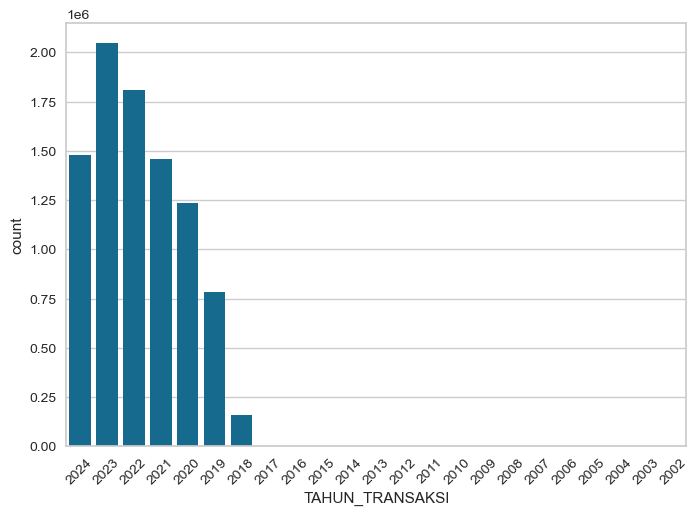

In [42]:
# Distribusi transaksi per tahun tahun 2002 s.d. 2024 dengan urutan tahun terbaru ke terlama

df_0224["TAHUN_TRANSAKSI"].value_counts().sort_index(ascending=False)
sns.countplot(x="TAHUN_TRANSAKSI", data=df_0224, order=df_0224["TAHUN_TRANSAKSI"].value_counts().sort_index(ascending=False).index)
plt.xticks(rotation=45)
plt.show()



##### 02. Distribusi Harga Tahun 2002 s.d. 2024

In [43]:
# Distribusi Harga - 1

df_0224["HARGA"].describe().apply(lambda x: f"{x:,.2f}")

count                8,967,076.00
mean               960,378,995.08
std          1,001,842,180,234.60
min                          0.00
25%                102,000,000.00
50%                200,000,000.00
75%                550,000,000.00
max      3,000,000,025,000,000.00
Name: HARGA, dtype: object

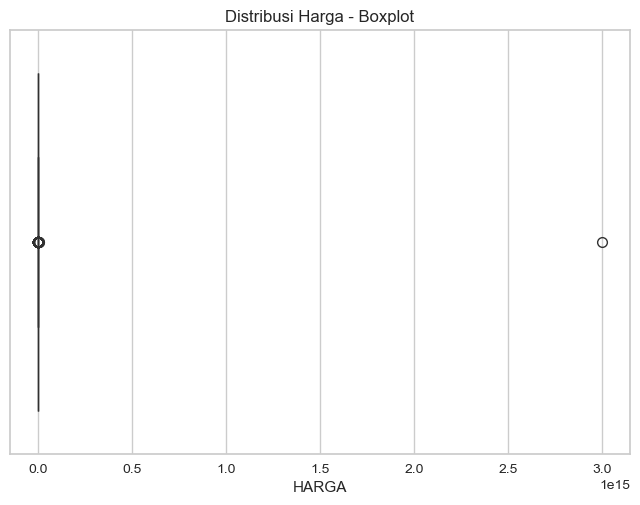

In [44]:
# Distribusi Harga - 2

sns.boxplot(x=df_0224["HARGA"])
plt.title("Distribusi Harga - Boxplot")
plt.show()

In [45]:
# Hapus data Harga Outlier (data max Harga)

df_0224.drop(df_0224["HARGA"].idxmax(), inplace=True)

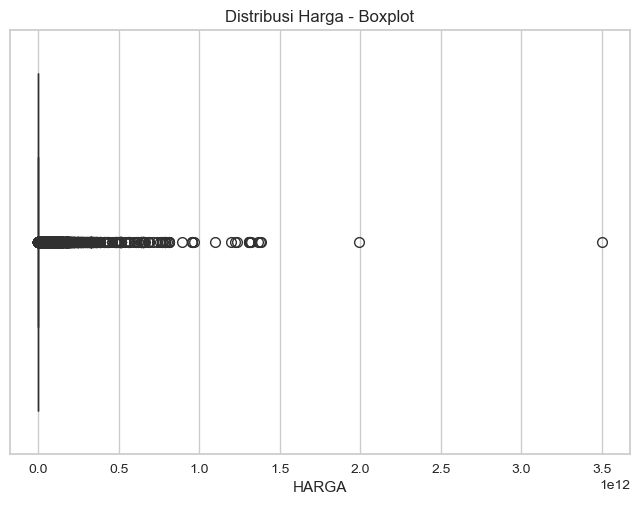

In [46]:
# Distribusi Harga - 2

sns.boxplot(x=df_0224["HARGA"])
plt.title("Distribusi Harga - Boxplot")
plt.show()

In [47]:
# lihat row data dengan harga tertinggi setelah menghapus max harga dan tampilkan pemisah ribuan

df_0224[df_0224["HARGA"] == df_0224["HARGA"].max()]

,nama_wp,tempat_lapor,nip_penerima,nama_penerima,KPPADM_NOTARIS,KPPADM_PEMBELI,KPPADM_PENJUAL,NOMOR_SURAT,TGL_SURAT,CREATION_DATE,...,HARGA,JML_PPHFINAL_TERUTANG,NTPN,TGL_BAYAR,JUMLAH_BAYAR,e_pphtbnotaris,TAHUN_SURAT,TAHUN_TRANSAKSI,TAHUN_BAYAR,JENIS_OBJEK_PAJAK
8678034,MANDIRI CIPTA GEMILANG,DJP ONLINE,-1.0,NaN,nan,nan,62.0,SKET-48/PHTB/WPJ.05/KP.1103/2021,2021-01-22,22-JAN-21 02.54.06.000000 PM,...,3500000000000,8.750000e+10,8622D742IEB28BBG,2021-01-22,8.750000e+10,N,2021,2021,2021,Tanah dan Bangunan


In [48]:
# Analisis Data setelah menghapus outlier pada kolom HARGA 

df_0224["HARGA"].describe().apply(lambda x: f"{x:,.2f}")

count            8,967,075.00
mean           625,821,844.10
std          4,062,286,240.75
min                      0.00
25%            102,000,000.00
50%            200,000,000.00
75%            550,000,000.00
max      3,500,000,000,000.00
Name: HARGA, dtype: object

##### 03. Wilayah dengan Transaksi Terbanyak Tahun 2023

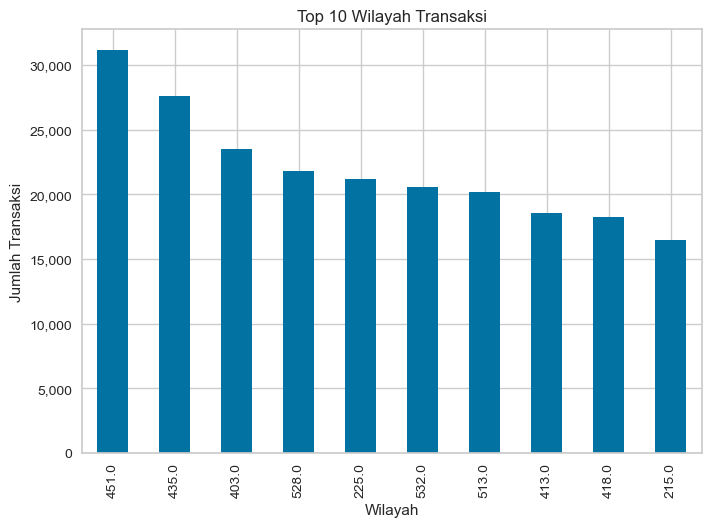

In [49]:
# KPP Lokasi Objek - Top 10 Wilayah Transaksi Tahun 2023 (Bukan 2024 karena masih sampai bulan Agustus)

df_2023 = df_0224[df_0224["TAHUN_BAYAR"] == 2023]

df_2023["KPP_LOKASI_OBJEK"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Wilayah Transaksi")
plt.xlabel("Wilayah")
plt.ylabel("Jumlah Transaksi")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

##### 04. Wilayah dengan Pembayaran PPhTB Terbesar Tahun 2023

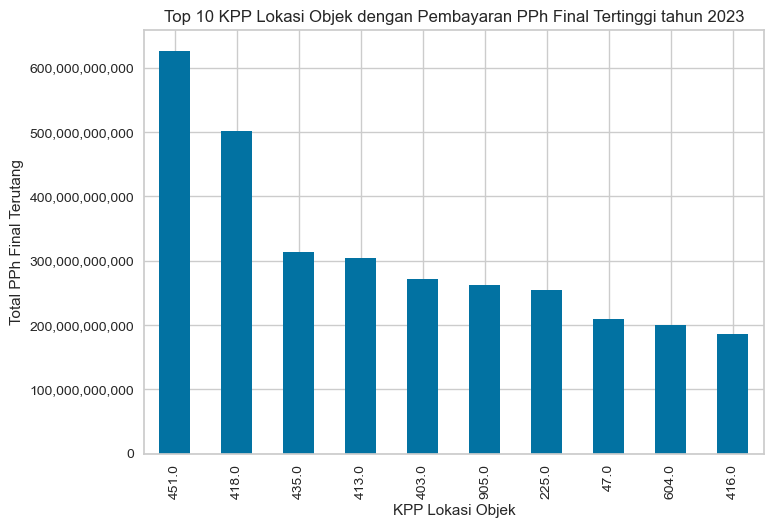

In [50]:
# KPP Lokasi Objek dengan pembayaran PPh Final tertinggi tahun 2023

df_2023[df_2023["TAHUN_BAYAR"] == 2023].groupby("KPP_LOKASI_OBJEK")["JML_PPHFINAL_TERUTANG"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 KPP Lokasi Objek dengan Pembayaran PPh Final Tertinggi tahun 2023")
plt.xlabel("KPP Lokasi Objek")
plt.ylabel("Total PPh Final Terutang")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

### 3. Data Preparation

##### 01. Drop Kolom

In [51]:
# Drop kolom yang tidak diperlukan untuk analisis lebih lanjut

columns_to_drop = [
    "nip_penerima",
    "nama_penerima",
    "NO_SK",
    "STATUS"
]
df_0224.drop(columns=columns_to_drop, inplace=True)

In [52]:
# Lihat info kolom penting setelah drop

cols = [
"HARGA",
"JUMLAH_BAYAR",
"JML_PPHFINAL_TERUTANG",
"LUAS_TANAH",
"LUAS_BANGUNAN"
]

pd.options.display.float_format = '{:,.0f}'.format

df_0224[cols].describe()

,HARGA,JUMLAH_BAYAR,JML_PPHFINAL_TERUTANG,LUAS_TANAH,LUAS_BANGUNAN
count,"8,967,075","8,967,075","8,967,075","8,967,075","8,967,075"
mean,"625,821,844","6,751,801","17,757,336","3,646","8,172"
std,"4,062,286,241","78,517,881","112,304,094","2,605,941","5,314,484"
min,0,1,0,0,0
25%,"102,000,000","530,000","1,700,000",60,12
50%,"200,000,000","1,523,000","5,522,677",87,36
75%,"550,000,000","4,105,500","16,250,000",160,75
max,"3,500,000,000,000","87,500,000,000","87,500,000,000","7,322,200,000","9,513,040,602"


##### 02. Drop Row

In [54]:
# Drop row HARGA = 0 karena tidak valid untuk analisis lebih lanjut

df_0224 = df_0224[df_0224["HARGA"] > 0]

In [55]:
# Hitung jumlah row df_0224

len(df_0224)

8966277

##### 03. Convert ke Parquet agar proses Modelling lebih cepat

In [56]:
# # Convert to Parquet

file = "C:/Users/910223073/OneDrive - Kemenkeu/Karejo/PJJ/10. Data Analytics/intro-python/MLFlow/4. PPHTB  999 - 15 10 2024.parquet"
df_0224.to_parquet(file)

In [57]:
# Baca file parquet untuk Data Analysis

file_parquet = "C:/Users/910223073/OneDrive - Kemenkeu/Karejo/PJJ/10. Data Analytics/intro-python/MLFlow/4. PPHTB  999 - 15 10 2024.parquet"
df_parquet = pd.read_parquet(file_parquet)
df_parquet.head()

,nama_wp,tempat_lapor,KPPADM_NOTARIS,KPPADM_PEMBELI,KPPADM_PENJUAL,NOMOR_SURAT,TGL_SURAT,CREATION_DATE,NPWP_NOTARIS,NAMA_NOTARIS,...,HARGA,JML_PPHFINAL_TERUTANG,NTPN,TGL_BAYAR,JUMLAH_BAYAR,e_pphtbnotaris,TAHUN_SURAT,TAHUN_TRANSAKSI,TAHUN_BAYAR,JENIS_OBJEK_PAJAK
0,CHOESNOEL AISYAH,None,626.0,nan,626.0,SKET-4707/PHTB/KPP.120703/2022,2022-10-11,11-OCT-22 09.34.12.891000 AM,640942785626000,ERNA TRI MOERHADIATI,...,600000000,"15,000,000",3AC663IED1J3LJ6C,2022-10-04,"15,000,000",Y,2022,2022,2022,Tanah dan Bangunan
1,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6308/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.45.56.065000 PM,243267531416000,MOHAMAD ABROR,...,21000000,"525,000",2D1345BANL29RJ2K,2023-12-15,"525,000",Y,2023,2023,2023,Tanah Kosong
2,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6278/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.06.29.978000 PM,243267531416000,MOHAMAD ABROR,...,252840000,"6,321,000",0D2A44ET7QA2K9DA,2023-12-15,"6,321,000",Y,2023,2023,2023,Tanah Kosong
3,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6307/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.42.17.892000 PM,243267531416000,MOHAMAD ABROR,...,321000000,"8,025,000",61C174ET7QFSQGFC,2023-12-15,"8,025,000",Y,2023,2023,2023,Tanah Kosong
4,IR.A.TOSSIN SUHARYA,None,416.0,29.0,73.0,SKET-6226/PHTB/KPP.081203/2023,2023-12-15,15-DEC-23 03.33.00.106000 PM,243267531416000,MOHAMAD ABROR,...,180000000,"4,500,000",CB7872M285D2C1SR,2023-12-15,"4,500,000",Y,2023,2023,2023,Tanah Kosong


##### 04. Feature Engineering (7 Featuers)

In [58]:
# 1. Total Ukuran Properti

df_parquet["TOTAL_LUAS"] = df_parquet["LUAS_TANAH"] + df_parquet["LUAS_BANGUNAN"]

In [70]:
# 2. Harga Per Total Luas

df_parquet["HARGA_PER_M2"] = df_parquet["HARGA"] / df_parquet["TOTAL_LUAS"]

In [ ]:
# 3. Rasio Bangunan

df_parquet["RASIO_BANGUNAN"] = np.where(
    df_parquet["LUAS_TANAH"] > 0, 
    df_parquet["LUAS_BANGUNAN"] / df_parquet["LUAS_TANAH"], 
    0  # Untuk apartemen, rasionya kita set 0 karena tidak ada perbandingan tanah
)

In [ ]:
# 4. Rasio Bayar

df_parquet["RASIO_BAYAR"] = df_parquet["JUMLAH_BAYAR"] / df_parquet["JML_PPHFINAL_TERUTANG"]

In [ ]:
# 5. Lama Waktu Bayar (dalam hari)

df_parquet["LAMA_WAKTU_BAYAR"] = (df_parquet["TGL_BAYAR"] - df_parquet["TGL_TRANSAKSI"]).dt.days

In [ ]:
# 6. Deviasi Harga Tanah per Wilayah (KPP_LOKASI_OBJEK) <0.5 → kemungkinan undervalue  >2 → kemungkinan overvalue

median_harga = df_parquet.groupby("KPP_LOKASI_OBJEK")["HARGA_PER_M2"].median()

df_parquet["MEDIAN_HARGA_WILAYAH"] = df_parquet["KPP_LOKASI_OBJEK"].map(median_harga)

df_parquet["DEVIASI_HARGA"] = df_parquet["HARGA_PER_M2"] / df_parquet["MEDIAN_HARGA_WILAYAH"]

In [ ]:
# 7. Aktivitas Wilayah

transaksi_wilayah = df_parquet["KPP_LOKASI_OBJEK"].value_counts()

df_parquet["AKTIVITAS_WILAYAH"] = df_parquet["KPP_LOKASI_OBJEK"].map(transaksi_wilayah)

##### 04. Visualisasi EDA Lanjutan

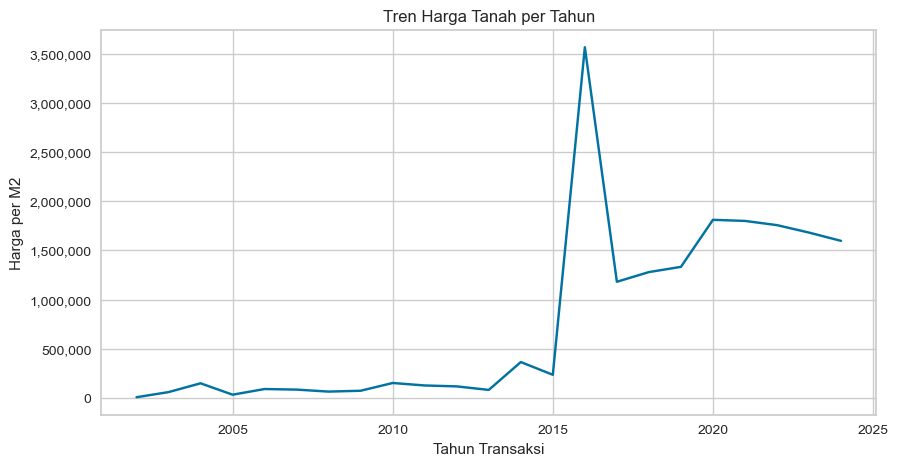

In [144]:
# Tren Harga Tanah per Tahun - 1

harga_tahun = df_parquet.groupby("TAHUN_TRANSAKSI")["HARGA_PER_M2"].median().sort_index(ascending=False)
harga_tahun.plot(figsize=(10, 5))
plt.title("Tren Harga Tanah per Tahun")
plt.xlabel("Tahun Transaksi")
plt.ylabel("Harga per M2")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

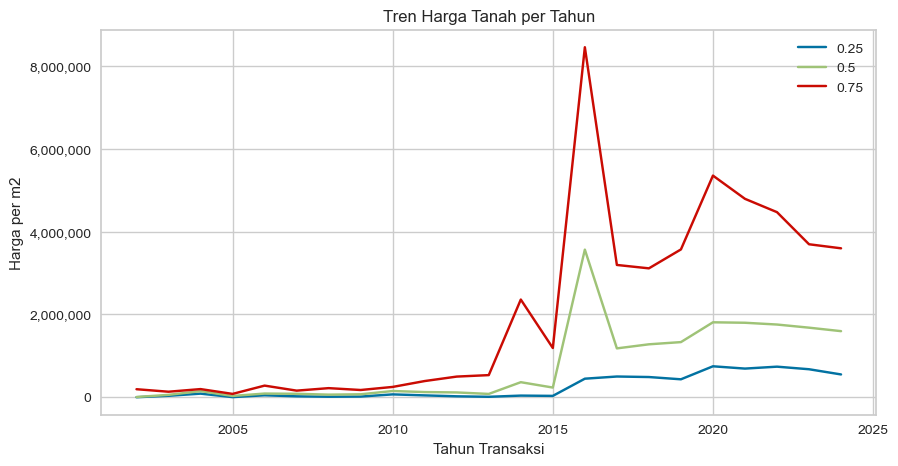

In [145]:
# Tren Harga Tanah per Tahun - 2 (Utk melihat di quantile berapa transaksi besar terjadi sehingga terjadi lonjakan ekstrem di sekitar tahun 2016)

harga_tahun = df_parquet.groupby("TAHUN_TRANSAKSI")["HARGA_PER_M2"].quantile([0.25, 0.5, 0.75]).unstack().sort_index(ascending=False)

harga_tahun.plot(figsize=(10, 5))
plt.title("Tren Harga Tanah per Tahun")
plt.xlabel("Tahun Transaksi")
plt.ylabel("Harga per m2")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

### 4. Modelling

#### A. Regresi

##### 01. Features

In [74]:
# Tetapkan Sampel = Seluruh Data Tahun Transaksi 2020 s.d. 2024 (Terdapat Perubahan Aturan yg menyebabkan Suket PPhTB dapat langsung diterbitkan tanpa PnKM) dan tidak termasuk Jenis Objek Pajak Data Tidak Valid (LUAS_TANAH = 0 dan LUAS_BANGUNAN = 0)
df_model = df_parquet[(df_parquet["TAHUN_TRANSAKSI"] >= 2020) & (df_parquet["TAHUN_TRANSAKSI"] <= 2024) & ((df_parquet["LUAS_TANAH"] > 0) | (df_parquet["LUAS_BANGUNAN"] > 0))]

In [75]:
df_model.shape

(8020148, 56)

In [84]:
# Label Encoding Lokasi (KPP_LOKASI_OBJEK)

le = LabelEncoder()
df_model["KPP_LOKASI_OBJEK_ENCODED"] = le.fit_transform(df_model["KPP_LOKASI_OBJEK"])

In [99]:
# Label Encoding Lokasi (JENIS_PENGALIHAN)

le_trans = LabelEncoder()
df_model["JENIS_PENGALIHAN_ENCODED"] = le_trans.fit_transform(df_model["JENIS_PENGALIHAN"])

In [85]:
# One-Hot Encoding Jenis Objek Pajak

df_model = pd.get_dummies(df_model, columns=["JENIS_OBJEK_PAJAK"], prefix="OBJEK")

KeyError: "None of [Index(['JENIS_OBJEK_PAJAK'], dtype='object')] are in the [columns]"

In [116]:
# Feature untuk model Regresi PPh

features_pph = [
'LUAS_TANAH', 
'LUAS_BANGUNAN', 
'RASIO_BANGUNAN', 
'JENIS_PENGALIHAN_ENCODED',
'KPP_LOKASI_OBJEK_ENCODED', 
'OBJEK_Tanah Kosong', 
'OBJEK_Tanah dan Bangunan', 
'OBJEK_Apartemen/Rumah Susun', 
'AKTIVITAS_WILAYAH', 
'MEDIAN_HARGA_WILAYAH'
]

X = df_model[features_pph]
y = np.log1p(df_model["HARGA"])

<Axes: >

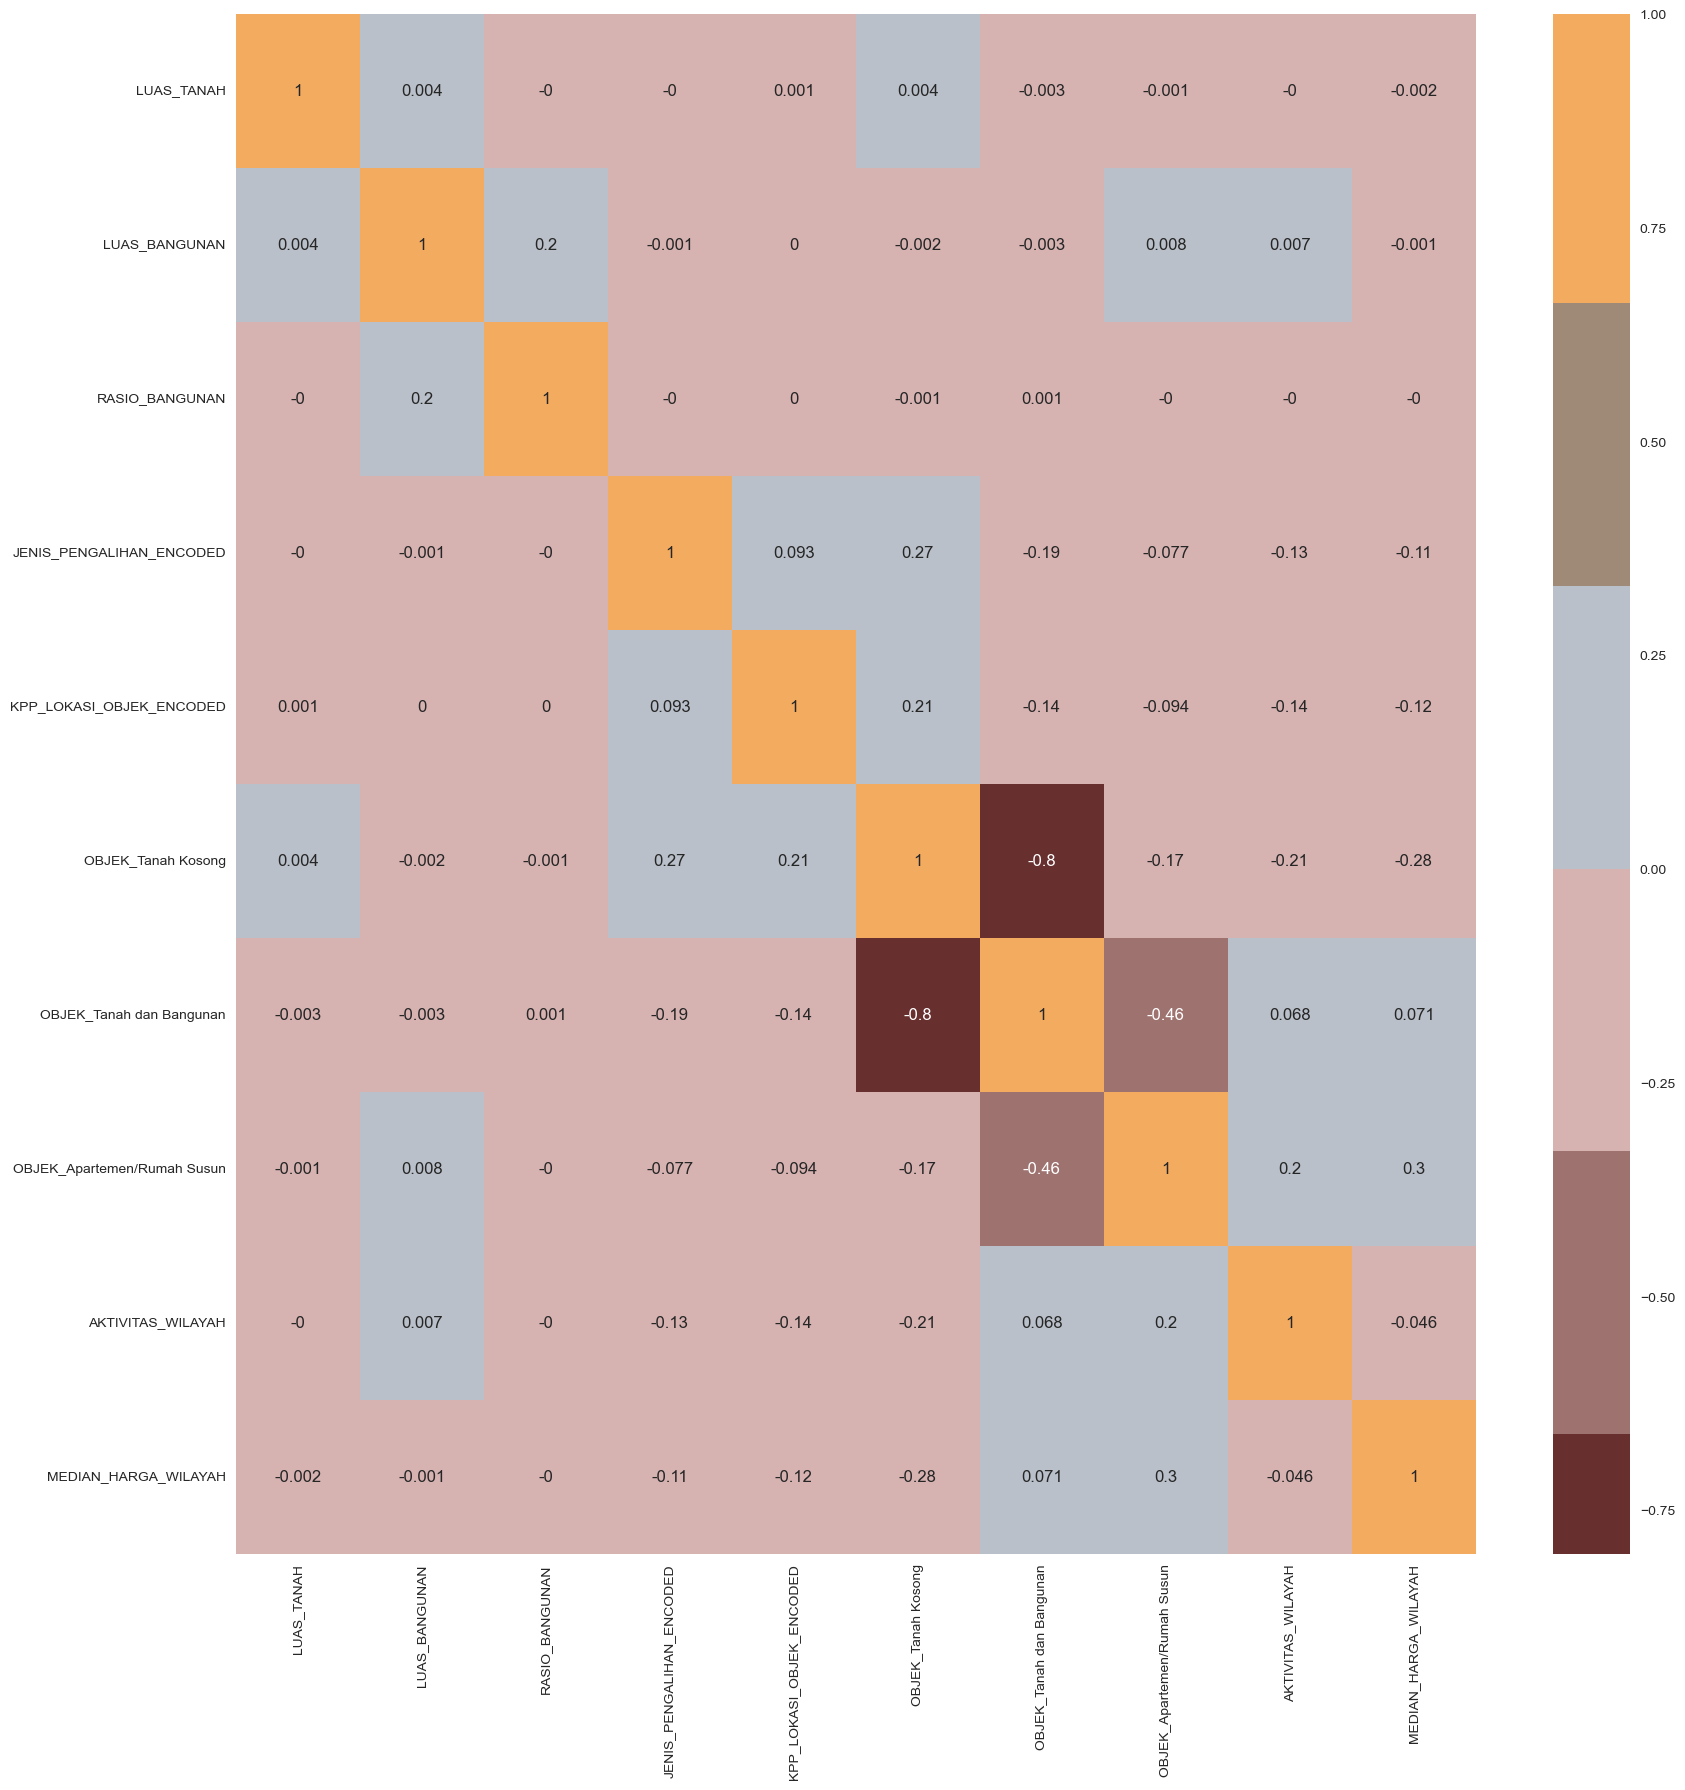

In [117]:
#correlation matrix dengan hanya 5 di belakang koma

cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])
corrmat= X.corr().round(3)
plt.figure(figsize=(20,20))  
sns.heatmap(corrmat,annot=True, cmap=cmap, center=0)

In [118]:
# Split data untuk training dan testing

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### 02. Linear Regression

In [126]:
# Model Linear Regresi

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

# Evaluasi Model Linear Regression dengan R-squared dan MAE

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:,.2f}")



R-squared: 0.1690
Mean Absolute Error: 0.92


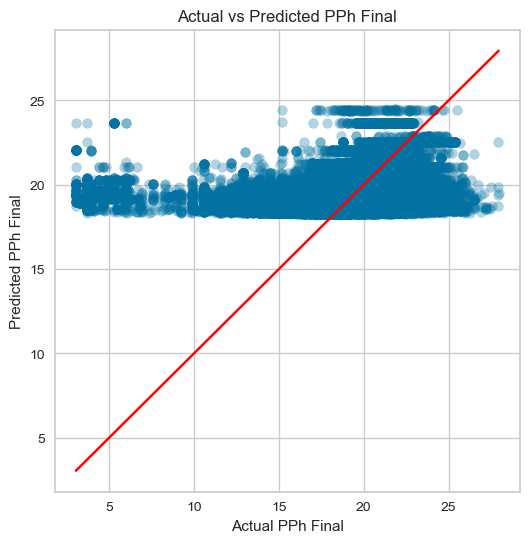

In [127]:
# Visualisasi Linear Regression - Prediksi vs Aktual

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual PPh Final")
plt.ylabel("Predicted PPh Final")

plt.title("Actual vs Predicted PPh Final")

plt.show()

##### 03. Random Forest

In [121]:
# Model Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf_model = RandomForestRegressor(
    n_estimators=50,      
    max_depth=10,       
    max_samples=0.05,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)

print(f"R2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

R2 Score: 0.503875590438075
Mean Absolute Error: 0.652894068753972


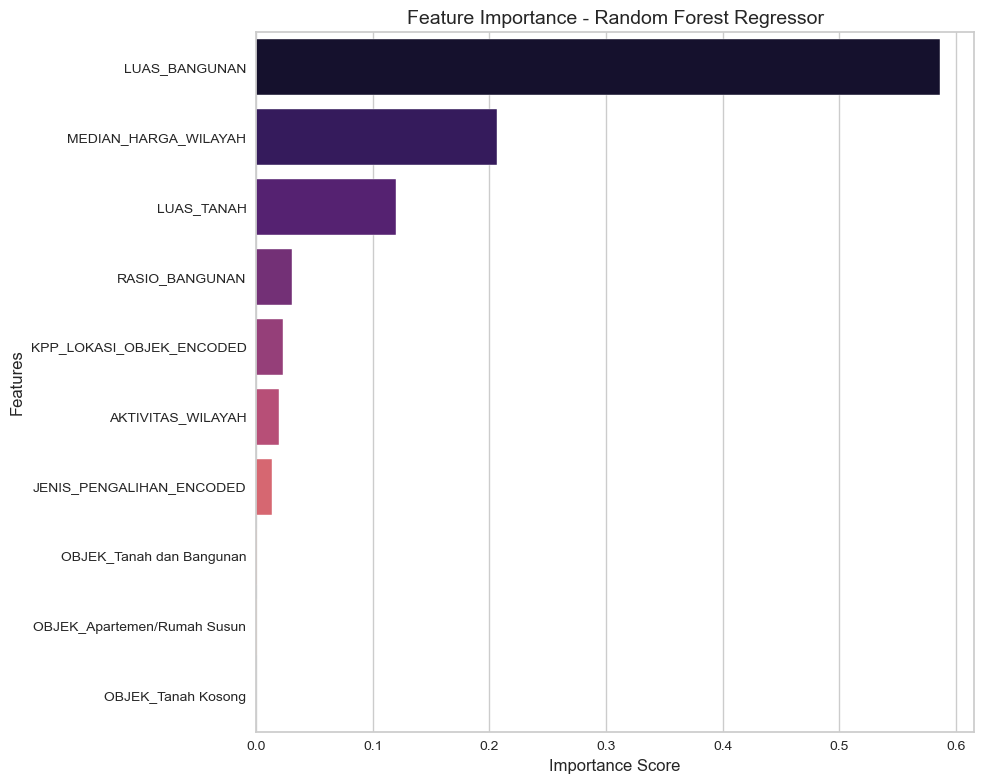

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengambil feature importance dari model Random Forest
rf_features = rf_model.feature_importances_

# 2. Membuat DataFrame untuk visualisasi (menggunakan kolom dari X_train)
importance_rf_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_features
}).sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_rf_df, 
    palette='magma' # Warna berbeda agar tidak tertukar dengan XGBoost
)

plt.title('Feature Importance - Random Forest Regressor', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

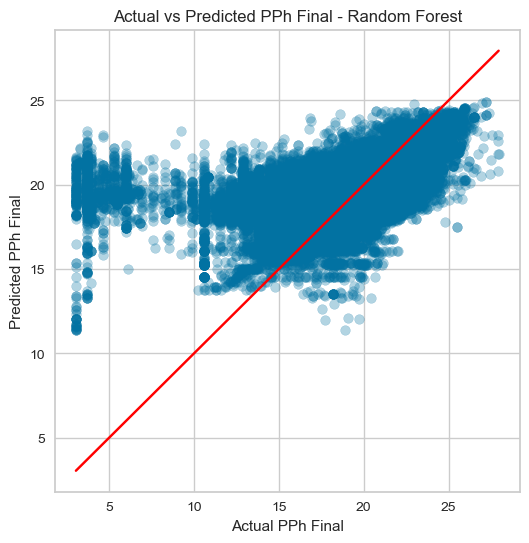

In [123]:
# Visualisasi Random Forest - Prediksi vs Aktual

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual PPh Final")
plt.ylabel("Predicted PPh Final")
plt.title("Actual vs Predicted PPh Final - Random Forest")
plt.show()

##### 04. Decision Tree

In [133]:
# Model Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,            
    min_samples_leaf=50,     
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f"Decision Tree R-squared: {r2_dt:.4f}")
print(f"Decision Tree Mean Absolute Error: {mae_dt:,.2f}")

Decision Tree R-squared: 0.4860
Decision Tree Mean Absolute Error: 0.66


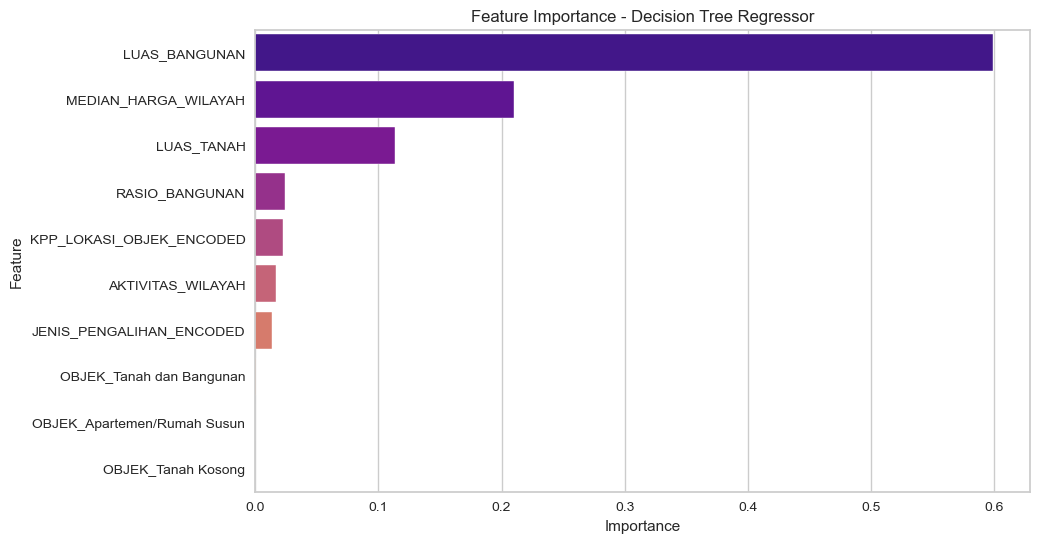

In [135]:
# Feature Importance Decision Tree Regressor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ambil feature importance dari Decision Tree
dt_features = dt_model.feature_importances_

# 2. Buat DataFrame untuk visualisasi
importance_dt_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_features
}).sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_dt_df, palette='plasma')
plt.title('Feature Importance - Decision Tree Regressor')
plt.show()

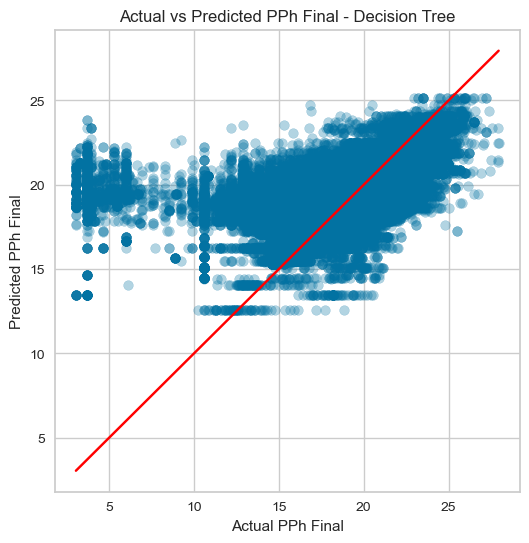

In [134]:
# Visualisasi Decision Tree - Prediksi vs Aktual

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual PPh Final")
plt.ylabel("Predicted PPh Final")
plt.title("Actual vs Predicted PPh Final - Decision Tree")
plt.show()

##### 05. Model XGBoost

In [122]:
# Model XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# convert ke numpy
# X_train_np = np.array(X_train)
# X_test_np = np.array(X_test)

# y_train_np = np.ravel(y_train)
# y_test_np = np.ravel(y_test)

# model
xgb_model = XGBRegressor(
    n_estimators=1000,
    max_depth=10,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

# evaluasi
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost R-squared: {r2_xgb:.4f}")
print(f"XGBoost Mean Absolute Error: {mae_xgb:,.2f}")

XGBoost R-squared: 0.6160
XGBoost Mean Absolute Error: 0.52


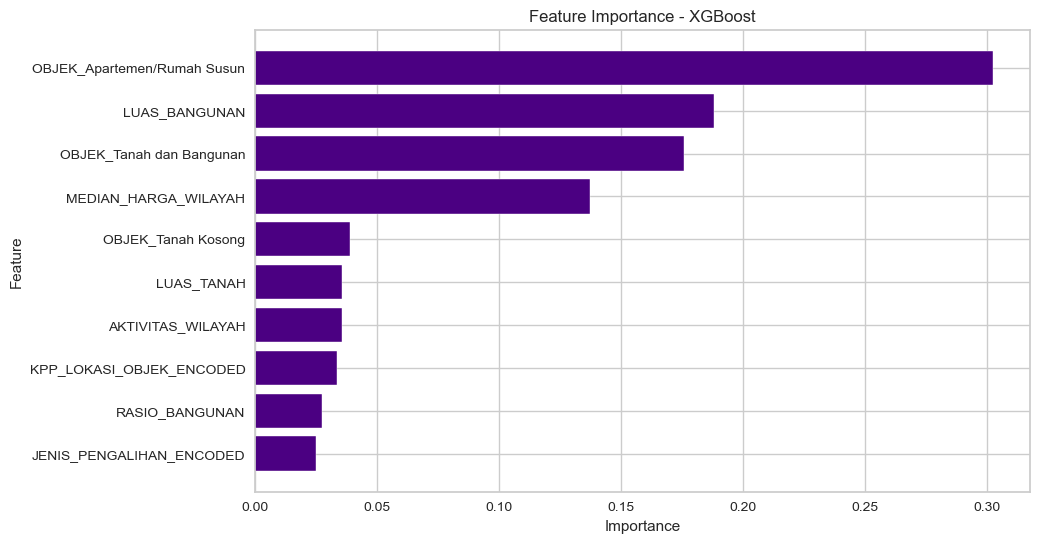

In [131]:
# Feature Importance
import matplotlib.pyplot as plt

# Mendapatkan feature importance dari model XGBoost
feature_importances = xgb_model.feature_importances_

# Membuat DataFrame untuk visualisasi
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances,
    'pallete': 'indigo'  # Warna berbeda agar tidak tertukar dengan Random Forest
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color=importance_df['pallete'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.show()

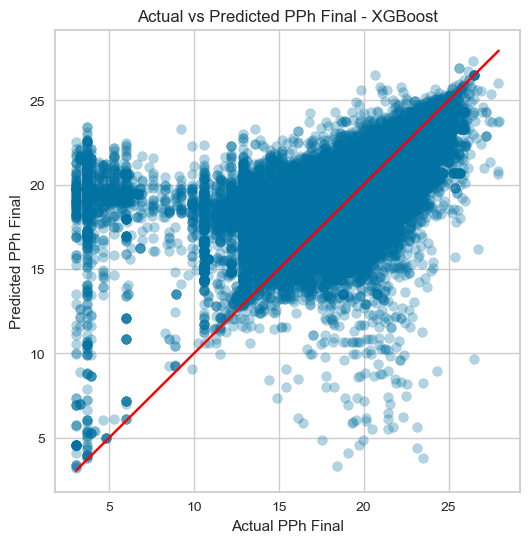

In [125]:
# Visualiasi XGBoost - Prediksi vs Aktual

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual PPh Final")
plt.ylabel("Predicted PPh Final")
plt.title("Actual vs Predicted PPh Final - XGBoost")
plt.show()

#### B. Clustering

##### 01. Cluster Property

In [ ]:
# Filter data HARGA_PER_M2 > 0

df_sample_mini_property = df_sample_mini[df_sample_mini["HARGA_PER_M2"] > 0]

In [ ]:
# Tetapkan Features

features_cluster = [
    "HARGA",
    "LUAS_TANAH",
    "LUAS_BANGUNAN",
    "HARGA_PER_M2"
]

X_property = df_sample_mini_property[features_cluster]

In [ ]:
# Scalling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_property = scaler.fit_transform(X_property)

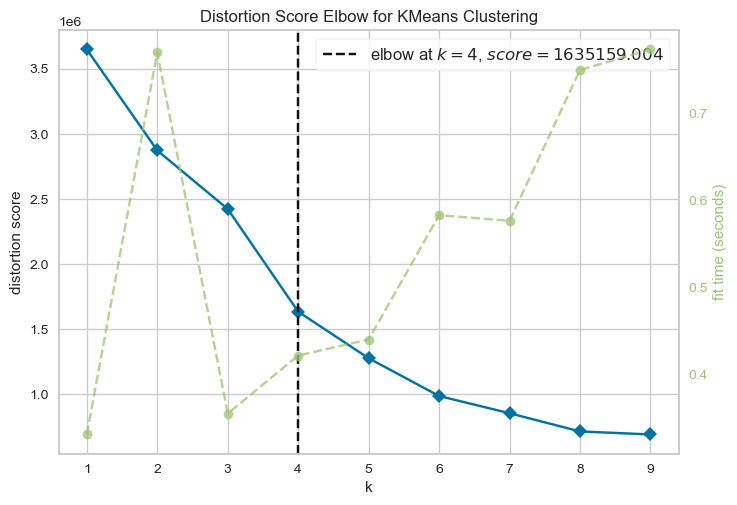

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Tentukan berapa elbow

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

Elbow_M = KElbowVisualizer(KMeans(), k=(1, 10))
Elbow_M.fit(X_scaled_property)
Elbow_M.show()


In [ ]:
# Clustering

kmeans = KMeans(n_clusters=4, random_state=42)
df_sample_mini_property["Cluster_Property"] = kmeans.fit_predict(X_scaled_property)

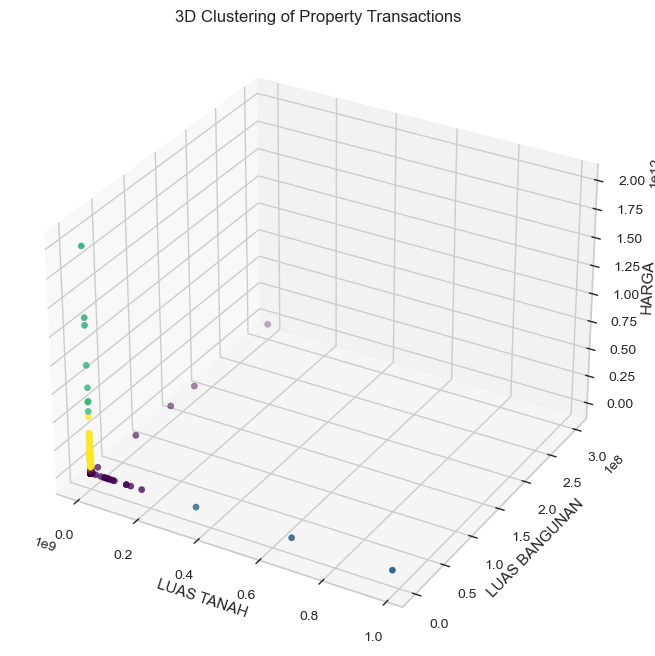

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_sample_mini_property["LUAS_TANAH"],
    df_sample_mini_property["LUAS_BANGUNAN"],
    df_sample_mini_property["HARGA"],
    c=df_sample_mini_property["Cluster_Property"],
    cmap="viridis"
)

ax.set_xlabel("LUAS TANAH")
ax.set_ylabel("LUAS BANGUNAN")
ax.set_zlabel("HARGA")

plt.title("3D Clustering of Property Transactions")
plt.show()

##### 02. Cluster Kepatuhan Bayar

In [ ]:
# Filter data RASIO_PPh > 0

df_sample_mini_tax = df_sample_mini[df_sample_mini["RASIO_PPh"] > 0]

In [ ]:
# Tetapkan Features

features_tax = [
    "HARGA",
    "JML_PPHFINAL_TERUTANG",
    "RASIO_PPh"
]

X_tax = df_sample_mini_tax[features_tax]

In [ ]:
# Scalling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_tax = scaler.fit_transform(X_tax)

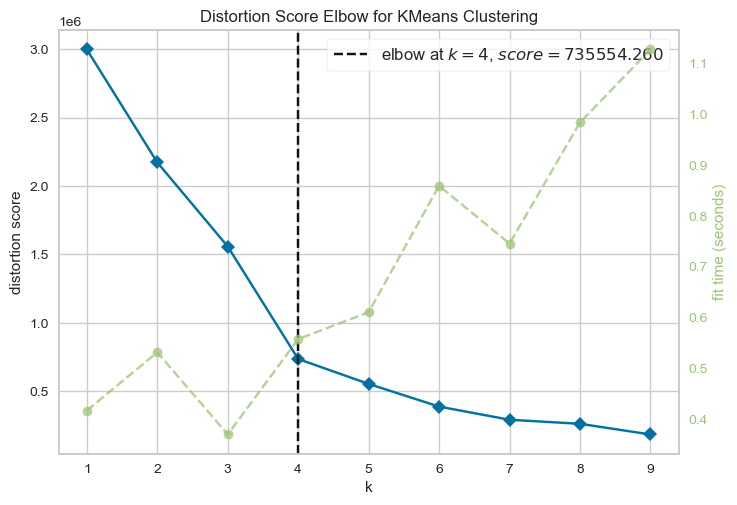

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Tentukan berapa elbow

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

Elbow_M = KElbowVisualizer(KMeans(), k=(1, 10))
Elbow_M.fit(X_scaled_tax)
Elbow_M.show()


In [ ]:
# Clustering

kmeans = KMeans(n_clusters=4, random_state=42)
df_sample_mini_tax["Cluster_Tax"] = kmeans.fit_predict(X_scaled_tax)

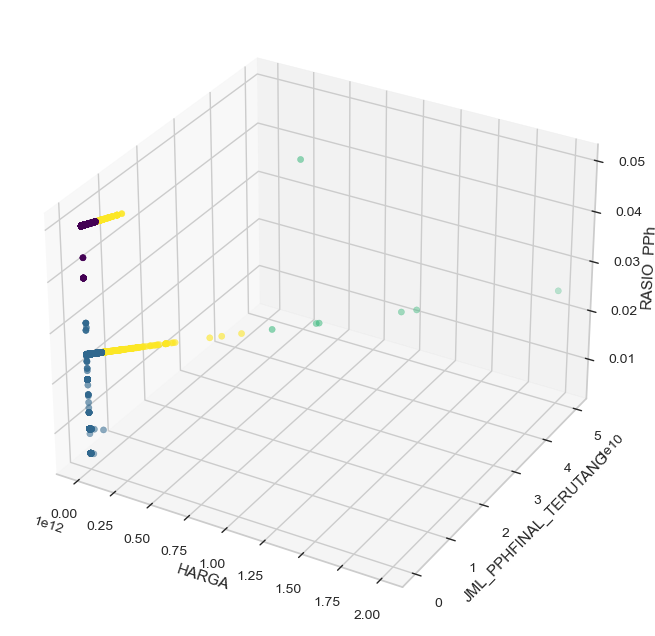

In [ ]:
# Visualisasi

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_sample_mini_tax["HARGA"],
    df_sample_mini_tax["JML_PPHFINAL_TERUTANG"],
    df_sample_mini_tax["RASIO_PPh"],
    c=df_sample_mini_tax["Cluster_Tax"],
    cmap="viridis"
)
ax.set_xlabel("HARGA")
ax.set_ylabel("JML_PPHFINAL_TERUTANG")
ax.set_zlabel("RASIO_PPh")
plt.show()

#### C. Anomaly Detection

In [ ]:
# 1. Prediksi seluruh data (atau data test saja)
y_pred_log = xgb_model.predict(X_test)

# 2. Balikkan dari skala Log ke Rupiah
y_actual_rp = np.expm1(y_test)
y_pred_rp = np.expm1(y_pred_log)

# 3. DataFrame Anomali
df_anomali = X_test.copy()
df_anomali['HARGA_LAPOR'] = y_actual_rp
df_anomali['HARGA_PREDIKSI'] = y_pred_rp

# 4. Hitung Selisih dan Rasio (Dibulatkan 2 angka belakang koma)
df_anomali['SELISIH_NOMINAL'] = df_anomali['HARGA_PREDIKSI'] - df_anomali['HARGA_LAPOR']
df_anomali['RASIO_VALIDASI'] = (df_anomali['HARGA_LAPOR'] / df_anomali['HARGA_PREDIKSI'])

# 5. Filter Anomali
kriteria_anomali = (df_anomali['RASIO_VALIDASI'] < 0.6) & (df_anomali['SELISIH_NOMINAL'] > 100_000_000)
daftar_audit = df_anomali[kriteria_anomali].sort_values(by='SELISIH_NOMINAL', ascending=False)

# 6. Tampilkan Hasil serta KPPADM Penjual
print("Daftar Anomali Transaksi PPHTB:")

pd.options.display.float_format = '{:,.2f}'.format

daftar_audit[['HARGA_LAPOR', 'HARGA_PREDIKSI', 'SELISIH_NOMINAL', 'RASIO_VALIDASI']].head(10).style.format({
    'HARGA_LAPOR': '{:,.0f}',
    'HARGA_PREDIKSI': '{:,.0f}',
    'SELISIH_NOMINAL': '{:,.0f}',
    'RASIO_VALIDASI': '{:.2f}'
})

Total kasus berisiko tinggi ditemukan: 149840


,HARGA_LAPOR,HARGA_PREDIKSI,SELISIH_NOMINAL,RASIO_VALIDASI
6640689,"308,655,788,300","728,915,116,032","420,259,327,732",0.42
2625315,"134,541,730,000","502,924,804,096","368,383,074,096",0.27
2625495,"134,541,730,000","502,924,804,096","368,383,074,096",0.27
774687,"922,801,425","320,530,186,240","319,607,384,815",0.00
9148409,"220,000,000,000","413,387,849,728","193,387,849,728",0.53
9153297,"1,236,625,000","164,844,437,504","163,607,812,504",0.01
2367938,"4,256,000,000","164,844,437,504","160,588,437,504",0.03
7367868,"1,400,000,000","137,479,667,712","136,079,667,712",0.01
2091075,"1,860,000,000","137,138,151,424","135,278,151,424",0.01
5752873,"422,000,000","135,283,720,192","134,861,720,192",0.00
